installing libraries

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

Doing EDA

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.shape

(891, 12)

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df.value_counts()

,,,,,,,,,,,,count
PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,1
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,1
873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,1
880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,1


In [12]:
# cabin drop
df = df.drop(columns=['Cabin'])

In [13]:
# filling null values in age
df['Age'] = df['Age'].fillna(df['Age'].median())

In [14]:
# filling embarked null values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Till now data is cleaned

NOW REMOVING UNNECASSERY COLUMNS

In [16]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Doing label encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:


# label encoding it means text into numerical values
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Feature engineering: Create FamilySize and drop SibSp and Parch
df['FamilySize'] = df['SibSp'] + df['Parch']
df = df.drop(columns = ['SibSp', 'Parch'])

df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,1,22.0,7.2500,2,1
1,1,1,0,38.0,71.2833,0,1
2,1,3,0,26.0,7.9250,2,0
3,1,1,0,35.0,53.1000,2,1
4,0,3,1,35.0,8.0500,2,0


In [19]:
# making X and Y variables
X = df.drop(columns = ['Survived'])
Y = df['Survived']

print("Features in X after preprocessing:", X.columns.tolist())

Features in X after preprocessing: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']


In [20]:
print(X)
print(Y)

     Pclass  Sex   Age     Fare  Embarked  FamilySize
0         3    1  22.0   7.2500         2           1
1         1    0  38.0  71.2833         0           1
2         3    0  26.0   7.9250         2           0
3         1    0  35.0  53.1000         2           1
4         3    1  35.0   8.0500         2           0
..      ...  ...   ...      ...       ...         ...
886       2    1  27.0  13.0000         2           0
887       1    0  19.0  30.0000         2           0
888       3    0  28.0  23.4500         2           3
889       1    1  26.0  30.0000         0           0
890       3    1  32.0   7.7500         1           0

[891 rows x 6 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


### Checking if the data is inbalanced

In [21]:
df['Survived'].value_counts()
# itna hi hai is datset mai

,count
Survived,
0,549
1,342


Correlation Heatmap

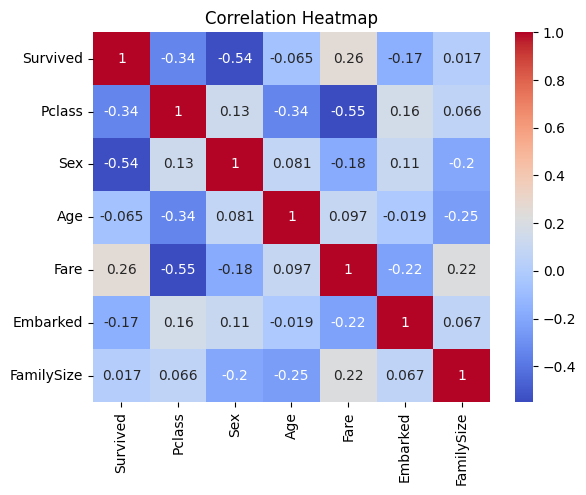

In [22]:
# Survived row mein jo number 0 se door hai — chahe positive ho ya negative — woh column important hai model ke liye.
# Heatmap se pata chala — Sex aur Pclass survival se sabse zyada related hain
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Spliting the data for model training

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# splitting train and test data
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(712, 6)
(179, 6)


# Logistic regression


In [25]:
# training the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [26]:
# checking accuracy
from sklearn.metrics import accuracy_score

y_predict = model.predict(X_test)
accuracy = accuracy_score(Y_test, y_predict)

print("Accuracy: ", accuracy)

Accuracy:  0.8044692737430168


# decision tree
now we moving towards decision tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

# training the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

# checking accuracy
dt_predict = dt_model.predict(X_test)
dt_accuracy = accuracy_score(Y_test, dt_predict)

print("Decision Tree Accuracy: ", dt_accuracy)

Decision Tree Accuracy:  0.7653631284916201


 # Model Comparison

#### Logistic Regression: 81%
#### Decision Tree: 78%
#### Winner: Logistic Regression — kyunki Decision Tree overfit ho gaya

------

# SVM & RANDOM FOREST

In [28]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# svm
svm_model = SVC(random_state=42)
svm_model.fit(X_train, Y_train)

# checking accuracy
svm_predict = svm_model.predict(X_test)
svm_accuracy = accuracy_score(Y_test, svm_predict)



# random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

# checking accuracy
rf_predict = rf_model.predict(X_test)
rf_accuracy = accuracy_score(Y_test, rf_predict)

# Comparison
print("Logistic Regression:", 0.81)
print("Decision Tree:", 0.78)
print("SVM:", svm_accuracy)
print("Random Forest:", rf_accuracy)

Logistic Regression: 0.81
Decision Tree: 0.78
SVM: 0.664804469273743
Random Forest: 0.8268156424581006


In [29]:
# Final Summary
print("Best Model: Random Forest")
print("Best Accuracy:", rf_accuracy)

Best Model: Random Forest
Best Accuracy: 0.8268156424581006


Saving the model

In [30]:
# saving model
import joblib

joblib.dump(rf_model, 'titanic_model.pkl')
print("Model saved!")

Model saved!
